Sharpe Ratio (Optimized Portfolio - CVaR): 0.09
Sharpe Ratio (Equally Weighted Portfolio): 0.07
Max Drawdown (Optimized Portfolio - CVaR): 26.07%
Max Drawdown (Equally Weighted Portfolio): 29.61%
S&P Sharpe Ratio: 0.12


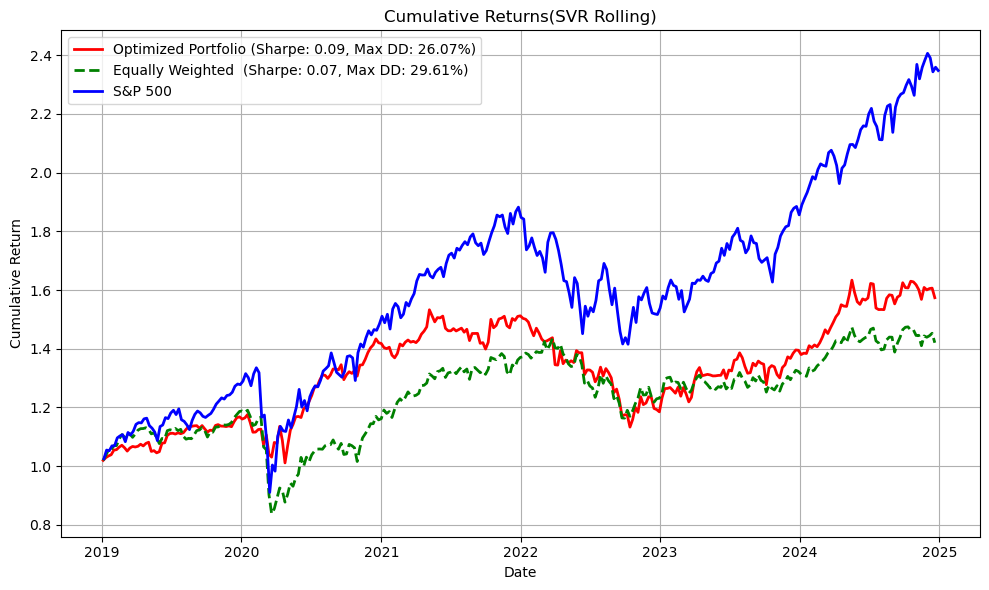

Out-of-Sample Metrics:
                 MSE        R2  Directional Accuracy  Spearman   Rank R2
es1_logret  0.000277  0.561228              0.830128  0.767935  0.589724
vg1_logret  0.000700  0.176746              0.682692  0.552979  0.305786
z1_logret   0.000375  0.414542              0.695513  0.541419  0.293134
rx1_logret  0.000145 -0.284397              0.586538  0.225619  0.050904
gc1_logret  0.000421  0.034910              0.679487  0.399610  0.159688
co1_logret  0.013024 -2.723701              0.660256  0.440407  0.193958
hg1_logret  0.000413  0.575361              0.772436  0.754917  0.569900


KeyError: 'rank_r2'

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.feature_selection import mutual_info_regression
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit  # not used in BayesSearchCV here
np.random.seed(42)
import warnings
warnings.filterwarnings("ignore")
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr

start_time = time.time() 

###############################################################################
# 1. CVaR, Objective
###############################################################################
def compute_cvar(historical_returns, weights, alpha=0.9):
    
    port_returns = np.dot(historical_returns, weights)
    sorted_returns = np.sort(port_returns)
    cutoff = int(np.floor((1 - alpha) * len(sorted_returns)))
    cutoff = max(cutoff, 0)
    worst_returns = sorted_returns[:cutoff+1]
    cvar = np.mean(worst_returns) if len(worst_returns) > 0 else sorted_returns[cutoff]
    return cvar

def cvar_objective(weights, predicted_returns, historical_returns, alpha=0.9, lambda_reg=0.01):
    
    eps = 1e-8
    port_return = np.dot(weights, predicted_returns)
    port_cvar = compute_cvar(historical_returns, weights, alpha=alpha)
    obj = - port_return / (abs(port_cvar) + eps) + lambda_reg * np.sum(weights**2)
    return obj

###############################################################################
# 2. SVR Hyperparameter Space
###############################################################################
svr_param_space = {
    'C':      Real(1e-1, 1e2, prior='log-uniform'),
    'epsilon':Real(1e-4, 1e-1, prior='log-uniform'),
    'gamma':  Real(1e-5, 1e-1, prior='log-uniform')
}

###############################################################################
# 3. Data
###############################################################################
price_data = pd.read_excel(
    r'C:\Users\orekh\Desktop\MMF\Thesis\Data\broader_weekly_data_filled.xlsx',
    parse_dates=["date"],
    index_col="date"
)

filtered_returns = price_data.iloc[:, :7]
filtered_features = price_data.iloc[:, 7:]

train_start_date = '2016-04-22'
train_end_date   = '2018-12-31'
test_start_date  = '2019-01-01'
test_end_date    = '2025-01-01'

split_date = pd.to_datetime(train_end_date)
split_idx = filtered_returns.index.searchsorted(split_date, side='right')

train_returns_full = filtered_returns.iloc[:split_idx]
test_returns_full  = filtered_returns.iloc[split_idx:]
train_features_full = filtered_features.iloc[:split_idx]
test_features_full  = filtered_features.iloc[split_idx:]

all_returns = pd.concat([train_returns_full, test_returns_full])
all_features = pd.concat([train_features_full, test_features_full])
all_returns.sort_index(inplace=True)
all_features.sort_index(inplace=True)
all_dates = all_returns.index

###############################################################################
# 3. Rolling Window
###############################################################################

test_start_idx = len(train_returns_full)

######################
# Rolling W parameters
######################
rolling_window_size = 78  
test_window_size = 12      
model_update_frequency_windows = 2 
rebalance_frequency = 2

# Containers
optimized_portfolio_returns_cvar = []
equally_weighted_returns_cvar = []
optimized_weights_list_cvar = []
all_test_dates_collected = []  
all_predictions = []         

# Containers for in-sample metrics
train_metrics = {
    asset: {
        "mse": [], 
        "r2": [], 
        "dir_acc": [], 
        "spearman": []
    }
    for asset in train_returns_full.columns
}

# Best parameters
best_params_tracker = {
    asset: [] for asset in train_returns_full.columns
}

svr_models_bo = {}
svr_features_bo = {} 
last_model_update = -model_update_frequency_windows 
window_counter = 0

# Initialize previous weights
n_assets = all_returns.shape[1]
prev_opt_weights = np.ones(n_assets) / n_assets

transaction_cost_rate = 0.0001
prev_forecast = None
###############################################################################
# 4. Rolling Window
###############################################################################
# Loop from the test start index to the end of the data
for i in range(test_start_idx, len(all_dates) - test_window_size + 1, test_window_size):
    # Ensure there is enough data for the training window.
    if i - rolling_window_size < 0:
        continue
    train_slice = slice(i - rolling_window_size, i)
    test_slice = slice(i, i + test_window_size)
    train_returns_chunk = all_returns.iloc[train_slice]
    train_features_chunk = all_features.iloc[train_slice]
    test_returns_chunk = all_returns.iloc[test_slice]
    test_features_chunk = all_features.iloc[test_slice]
    
    # Scaling
    scaler = StandardScaler()
    train_features_scaled = pd.DataFrame(
        scaler.fit_transform(train_features_chunk),
        index=train_features_chunk.index,
        columns=train_features_chunk.columns
    )
    test_features_scaled = pd.DataFrame(
        scaler.transform(test_features_chunk),
        index=test_features_chunk.index,
        columns=test_features_chunk.columns
    )
    
    # Adaptive feature selection via MI
    selected_features = {}
    for asset in train_returns_chunk.columns:
        mi_scores = mutual_info_regression(train_features_scaled, train_returns_chunk[asset], random_state=42)
        threshold = np.percentile(mi_scores, 60)
        keep_idxs = np.where(mi_scores >= threshold)[0]
        selected_features[asset] = train_features_scaled.columns[keep_idxs]
    
    # Retrain SVR model
    if (window_counter - last_model_update) >= model_update_frequency_windows:
        svr_models_bo = {}
        svr_features_bo = {}
        for asset in train_returns_chunk.columns:
            X_train = train_features_scaled[selected_features[asset]].values
            y_train = train_returns_chunk[asset]
            if X_train.shape[0] > 0 and X_train.shape[1] > 0:
                opt = BayesSearchCV(
                    SVR(),
                    svr_param_space, 
                    n_iter=25,
                    cv=TimeSeriesSplit(n_splits=3),
                    n_jobs=-1,
                    scoring='neg_mean_squared_error',
                    random_state=42
                )
                opt.fit(X_train, y_train)
                svr_models_bo[asset] = opt.best_estimator_
                svr_features_bo[asset] = selected_features[asset]
                best_params_tracker[asset].append(opt.best_params_)
        last_model_update = window_counter
    
    # In-Sample predictions & metrics for the training chunk
    train_predictions_df = pd.DataFrame(index=train_returns_chunk.index,
                                        columns=train_returns_chunk.columns)
    for asset in train_returns_chunk.columns:
        # Use the stored feature subset 
        feature_subset = svr_features_bo.get(asset, selected_features[asset])
        X_train_asset = train_features_scaled[feature_subset]
        if asset in svr_models_bo and X_train_asset.shape[1] > 0:
            train_predictions_df[asset] = svr_models_bo[asset].predict(X_train_asset)
        else:
            train_predictions_df[asset] = 0.0

    # Compute in-sample metrics
    for asset in train_returns_chunk.columns:
        y_true = train_returns_chunk[asset]
        y_pred = train_predictions_df[asset]
        mse_val = mean_squared_error(y_true, y_pred)
        rmse_val = np.sqrt(mse_val)
        mae_val = mean_absolute_error(y_true, y_pred)
        r2_val = r2_score(y_true, y_pred)
        dir_acc = np.mean(np.sign(y_true) == np.sign(y_pred))
        spearman_corr, _ = spearmanr(y_true, y_pred)
        rank_r2 = spearman_corr**2
        
        train_metrics[asset]["mse"].append(mse_val)
        train_metrics[asset]["r2"].append(r2_val)
        train_metrics[asset]["dir_acc"].append(dir_acc)
        train_metrics[asset]["spearman"].append(spearman_corr)
    
    # Out-of-Sample Predictions,test chunk
    predictions_df = pd.DataFrame(index=test_returns_chunk.index,
                                  columns=test_returns_chunk.columns)
    for asset in test_returns_chunk.columns:
        # Use the stored feature subset if available.
        feature_subset = svr_features_bo.get(asset, selected_features[asset])
        X_test_asset = test_features_scaled[feature_subset]
        if asset in svr_models_bo and X_test_asset.shape[1] > 0:
            predictions_df[asset] = svr_models_bo[asset].predict(X_test_asset)
        else:
            predictions_df[asset] = 0.0
    all_predictions.append(predictions_df.copy())
    
    # Portfolio Optimization 
    # For T+1 we use the forecast made at period T
    for t in range(0, len(test_returns_chunk)):
        date_t = test_returns_chunk.index[t]
        all_test_dates_collected.append(date_t)
        if t == 0:
            if prev_forecast is not None:
                expected_returns = prev_forecast 
            else:
                expected_returns = predictions_df.iloc[0].fillna(0).values
        else:
            expected_returns = predictions_df.iloc[t-1].fillna(0).values
        # use info from period t-1 to forecast t.
        if (t-1) % rebalance_frequency == 0:
            expected_returns = predictions_df.iloc[t-1].fillna(0).values
            historical_returns_scenarios = train_returns_chunk.values 
            n_assets = len(expected_returns)
            init_guess = np.ones(n_assets) / n_assets
            bounds = [(0, 1)] * n_assets
            constraints = [
                {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
                {'type': 'ineq', 'fun': lambda w: 0.4 - np.max(w)},
                {'type': 'ineq', 'fun': lambda w: np.min(w) - 0.0}
            ]
            res = minimize(
                cvar_objective,
                init_guess,
                args=(expected_returns, historical_returns_scenarios, 0.95, 0.01),
                method='SLSQP',
                bounds=bounds,
                constraints=constraints
            )
            new_weights = res.x if res.success else init_guess
            turnover = np.sum(np.abs(new_weights - prev_opt_weights))
            cost = transaction_cost_rate * turnover
            prev_opt_weights = new_weights.copy()
            w_opt = new_weights
        else:
            # No rebalancing: maintain previous weights
            w_opt = prev_opt_weights
            cost = 0
        
        realized_return = test_returns_chunk.iloc[t].values
        port_return_opt = np.dot(w_opt, realized_return)
        net_return = port_return_opt - cost
        optimized_portfolio_returns_cvar.append(net_return)
        
        # Equally weighted
        eq_weights = np.ones(n_assets) / n_assets
        eq_return = np.dot(eq_weights, realized_return)
        equally_weighted_returns_cvar.append(eq_return)
    
    window_counter += 1

###############################################################################
# 5. Cumulative returns and performance metrics
###############################################################################
optimized_cumulative_returns = (1 + np.array(optimized_portfolio_returns_cvar)).cumprod()
equally_weighted_cumulative_returns = (1 + np.array(equally_weighted_returns_cvar)).cumprod()

def calculate_sharpe_ratio(returns, risk_free_rate=0):
    excess_returns = np.array(returns) - risk_free_rate
    return np.mean(excess_returns) / (np.std(excess_returns, ddof=1) + 1e-9)

def calculate_max_drawdown(cumulative_returns):
    cumulative_max = np.maximum.accumulate(cumulative_returns)
    drawdowns = (cumulative_max - cumulative_returns) / cumulative_max
    return np.max(drawdowns)

sharpe_optimized = calculate_sharpe_ratio(optimized_portfolio_returns_cvar)
sharpe_equal = calculate_sharpe_ratio(equally_weighted_returns_cvar)
max_drawdown_optimized = calculate_max_drawdown(optimized_cumulative_returns)
max_drawdown_equal = calculate_max_drawdown(equally_weighted_cumulative_returns)

print(f"Sharpe Ratio (Optimized Portfolio - CVaR): {sharpe_optimized:.2f}")
print(f"Sharpe Ratio (Equally Weighted Portfolio): {sharpe_equal:.2f}")
print(f"Max Drawdown (Optimized Portfolio - CVaR): {max_drawdown_optimized:.2%}")
print(f"Max Drawdown (Equally Weighted Portfolio): {max_drawdown_equal:.2%}")

###############################################################################
# 6. S&P returns
###############################################################################
sp_data = pd.read_excel(
    r'C:\Users\orekh\Desktop\MMF\Thesis\Data\s_p_ret.xlsx',
    parse_dates=["date"],
    index_col="date"
)
sp_returns = sp_data['sp_ret']
sp_returns = sp_returns.loc[test_start_date:test_end_date]
sp_cumulative_returns = (1 + sp_returns).cumprod()
sharpe_sp = calculate_sharpe_ratio(sp_returns)
print(f"S&P Sharpe Ratio: {sharpe_sp:.2f}")

###############################################################################
# 7. Plot 
###############################################################################
plt.figure(figsize=(10, 6))
plt.plot(all_test_dates_collected, optimized_cumulative_returns,
         label=f'Optimized Portfolio (Sharpe: {sharpe_optimized:.2f}, Max DD: {max_drawdown_optimized:.2%})',
         color='red', linewidth=2)
plt.plot(all_test_dates_collected, equally_weighted_cumulative_returns,
         label=f'Equally Weighted  (Sharpe: {sharpe_equal:.2f}, Max DD: {max_drawdown_equal:.2%})',
         color='green', linestyle='--', linewidth=2)
plt.plot(sp_cumulative_returns.index, sp_cumulative_returns, label='S&P 500', color='blue', linewidth=2)
plt.title('Cumulative Returns(SVR Rolling)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

###############################################################################
# 8. Out-of-sample metrics
###############################################################################
predicted_returns_df = pd.concat(all_predictions).sort_index()
actual_returns = all_returns.loc[predicted_returns_df.index]

performance_metrics = {}
directional_accuracy_per_asset = {}
rank_correlation_per_asset = {}
rank_based_r2_per_asset = {}

for asset in actual_returns.columns:
    y_true = actual_returns[asset]
    y_pred = predicted_returns_df[asset]
    mse_val = mean_squared_error(y_true, y_pred)
    rmse_val = np.sqrt(mse_val)
    mae_val = mean_absolute_error(y_true, y_pred)
    r2_val = r2_score(y_true, y_pred)

    performance_metrics[asset] = {
        "MSE": mse_val,
        "R-squared": r2_val
    }

    # Directional accuracy/spearman
    actual_dir = np.sign(y_true.values)
    predicted_dir = np.sign(y_pred.values)
    directional_accuracy = np.mean(actual_dir == predicted_dir)
    directional_accuracy_per_asset[asset] = directional_accuracy
    spearman_corr, _ = spearmanr(y_true, y_pred)
    rank_correlation_per_asset[asset] = spearman_corr
    rank_based_r2_per_asset[asset] = spearman_corr**2

out_sample_summary = {}
for asset in performance_metrics.keys():
    out_sample_summary[asset] = {
         "MSE": performance_metrics[asset]["MSE"],
         "R2": performance_metrics[asset]["R-squared"],
         "Directional Accuracy": directional_accuracy_per_asset.get(asset, np.nan),
         "Spearman": rank_correlation_per_asset.get(asset, np.nan),
    }

out_sample_summary_df = pd.DataFrame(out_sample_summary).T
print("Out-of-Sample Metrics:")
print(out_sample_summary_df)

###############################################################################
# 9. Construct a Table of In-Sample Metrics per Asset
###############################################################################
in_sample_summary = {}
for asset, metrics in train_metrics.items():
    in_sample_summary[asset] = {
         "MSE": np.mean(metrics["mse"]) if metrics["mse"] else None,
         "R2": np.mean(metrics["r2"]) if metrics["r2"] else None,
         "Directional Accuracy": np.mean(metrics["dir_acc"]) if metrics["dir_acc"] else None,
         "Spearman": np.mean(metrics["spearman"]) if metrics["spearman"] else None,
    }
in_sample_summary_df = pd.DataFrame(in_sample_summary).T
print("In-Sample Performance Metrics per Asset:")
print(in_sample_summary_df)
